In [1]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---- ----------------------------------- 2.6/24.4 MB 25.1 MB/s eta 0:00:01
   --------- ------------------------------ 5.5/24.4 MB 16.0 MB/s eta 0:00:02
   ------------- -------------------------- 8.4/24.4 MB 14.9 MB/s eta 0:00:02
   ---------------- ----------------------- 10.2/24.4 MB 13.6 MB/s eta 0:00:02
   ------------------- -------------------- 12.1/24.4 MB 12.6 MB/s eta 0:00:01
   ----------------------- ---------------- 14.2/24.4 MB 11.9 MB/s eta 0:00:01
   -------------------------- ------------- 16.3/24.4 MB 11.6 MB/s eta 0:00:01
   ------------------------------ --------- 18.6/24.4 MB 11.5 MB/s eta 0:00:01
   ---------------------------------- ----- 21.0/24.4 MB 11.4 MB/s eta 0:00:01
   -------------------------------------- - 23.3/24.4 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 10.9 MB/


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import gensim
import os

In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [6]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

story = []
for filename in os.listdir('data'):
    f = open(os.path.join('data', filename))
    corpus = f.read()
    raw_sent = sent_tokenize(corpus)
    for sent in raw_sent:
        story.append(simple_preprocess(sent)) # performs basic level preprocessing on each sentence

In [9]:
# story is a 2d vector with each sentence is an array (1d vector) where each sentence is tokenized into words 
story

[['game',
  'of',
  'thrones',
  'book',
  'one',
  'of',
  'song',
  'of',
  'ice',
  'and',
  'fire',
  'by',
  'george',
  'martin',
  'prologue',
  'we',
  'should',
  'start',
  'back',
  'gared',
  'urged',
  'as',
  'the',
  'woods',
  'began',
  'to',
  'grow',
  'dark',
  'around',
  'them'],
 ['the', 'wildlings', 'are', 'dead'],
 ['do', 'the', 'dead', 'frighten', 'you'],
 ['ser',
  'waymar',
  'royce',
  'asked',
  'with',
  'just',
  'the',
  'hint',
  'of',
  'smile'],
 ['gared', 'did', 'not', 'rise', 'to', 'the', 'bait'],
 ['he',
  'was',
  'an',
  'old',
  'man',
  'past',
  'fifty',
  'and',
  'he',
  'had',
  'seen',
  'the',
  'lordlings',
  'come',
  'and',
  'go'],
 ['dead', 'is', 'dead', 'he', 'said'],
 ['we', 'have', 'no', 'business', 'with', 'the', 'dead'],
 ['are', 'they', 'dead'],
 ['royce', 'asked', 'softly'],
 ['what', 'proof', 'have', 'we'],
 ['will', 'saw', 'them', 'gared', 'said'],
 ['if',
  'he',
  'says',
  'they',
  'are',
  'dead',
  'that',
  'proof',


In [11]:
# building a model
model = gensim.models.Word2Vec(
    window = 10, # window size
    min_count = 2, # taking only those sentences that have atleast 2 words
)

In [12]:
# building the vocabulary 
model.build_vocab(story)

In [13]:
# training the deep learning model
# total_examples: total sentences in the corpus
model.train(story, total_examples=model.corpus_count, epochs=model.epochs)

(6569556, 8628190)

In [14]:
model.wv.most_similar('daenerys')

[('stormborn', 0.7905066609382629),
 ('targaryen', 0.7478498220443726),
 ('princess', 0.7240305542945862),
 ('myrcella', 0.7221611142158508),
 ('unburnt', 0.7131367921829224),
 ('elia', 0.6952875256538391),
 ('margaery', 0.6852638125419617),
 ('queen', 0.6687955856323242),
 ('dorne', 0.6605158448219299),
 ('viserys', 0.6560371518135071)]

In [15]:
model.wv.doesnt_match(['jon', 'rikon', 'arya', 'sansa', 'bran'])

'jon'

In [16]:
model.wv['king']

array([ 0.7274048 , -0.76897675,  2.877476  ,  2.2333388 , -3.319904  ,
        0.7477205 , -0.25265762,  0.84194285, -3.365597  , -1.0220762 ,
       -1.4396993 , -1.0415901 , -0.3023133 ,  1.6338911 , -2.9044497 ,
       -1.5190667 , -0.9912813 ,  1.8267866 ,  0.11623635, -1.0556593 ,
        1.3651576 , -1.5166503 ,  3.749606  , -2.3992321 , -2.0933552 ,
        0.4952669 , -2.3241484 , -0.43207675,  0.16519031,  1.2006046 ,
       -1.6683522 ,  0.11160854, -0.1733451 , -1.0470351 ,  1.6015855 ,
       -3.2125332 , -0.7362256 , -0.08897902,  1.6124737 , -1.7957605 ,
       -0.6178375 ,  2.6759586 ,  2.966574  ,  0.68562126, -0.6737366 ,
       -1.9657967 ,  0.2858231 , -2.5355403 ,  2.5310647 , -3.5172184 ,
       -3.7214348 , -0.54964525, -1.8361758 , -2.6057594 ,  4.333789  ,
       -2.0167842 ,  0.62697756, -0.3710052 ,  1.7612274 ,  1.4303747 ,
        2.189235  ,  1.4794575 , -1.1062939 , -0.52506965,  0.54084945,
        1.0288008 , -0.9603639 , -1.594157  ,  0.9302948 ,  0.20

In [17]:
model.wv['king'].shape

(100,)

In [18]:
model.wv.similarity('arya', 'sansa')

np.float32(0.8475618)

In [20]:
# to get vector representation of all words 
model.wv.get_normed_vectors()

array([[-0.09035226, -0.0228751 ,  0.11539814, ..., -0.02679208,
        -0.02272246,  0.01329186],
       [ 0.00338171, -0.10485445,  0.10463694, ..., -0.09899584,
        -0.09807273,  0.16768117],
       [ 0.06603662, -0.01010838, -0.00128173, ...,  0.00287207,
         0.09815843, -0.13794896],
       ...,
       [ 0.07999676, -0.03353097, -0.0207151 , ...,  0.07347853,
         0.07450231, -0.17025915],
       [ 0.10932818, -0.01783033,  0.15082532, ..., -0.1589409 ,
         0.1778145 , -0.13401467],
       [ 0.18090676, -0.04517442,  0.06902268, ..., -0.00021763,
         0.0274334 , -0.19139442]], shape=(17453, 100), dtype=float32)

In [23]:
# getting word for each vector
y = model.wv.index_to_key
y

['the',
 'and',
 'to',
 'of',
 'he',
 'his',
 'was',
 'you',
 'her',
 'in',
 'it',
 'had',
 'that',
 'she',
 'as',
 'with',
 'him',
 'not',
 'but',
 'for',
 'they',
 'is',
 'at',
 'on',
 'said',
 'my',
 'have',
 'be',
 'lord',
 'them',
 'no',
 'from',
 'would',
 'were',
 'me',
 'your',
 'one',
 'all',
 'when',
 'will',
 'ser',
 'if',
 'so',
 'their',
 'we',
 'could',
 'are',
 'man',
 'there',
 'this',
 'up',
 'been',
 'what',
 'did',
 'by',
 'king',
 'do',
 'men',
 'back',
 'out',
 'more',
 'or',
 'who',
 'down',
 'well',
 'than',
 'only',
 'like',
 'jon',
 'some',
 'father',
 'old',
 'hand',
 'even',
 'too',
 'tyrion',
 'before',
 'never',
 'an',
 'off',
 'know',
 'see',
 'into',
 'made',
 'now',
 'eyes',
 'black',
 'told',
 'lady',
 'thought',
 'time',
 'then',
 'how',
 'long',
 'has',
 'can',
 'might',
 'us',
 'come',
 'where',
 'here',
 'through',
 'face',
 'still',
 'head',
 'red',
 'll',
 'way',
 'boy',
 'page',
 'must',
 'once',
 'queen',
 'good',
 'two',
 'brother',
 'night',
 

In [24]:
# plotting all vectors (but first reducing the dimensions from 100 to 3 using PCA)
from sklearn.decomposition import PCA
pca = PCA(n_components=3)

In [28]:
# applying pca
X = pca.fit_transform(model.wv.get_normed_vectors())

In [32]:
X[:5]

array([[ 0.14461361,  0.6083064 , -0.08358623],
       [ 0.1898938 ,  0.33577657, -0.00358547],
       [-0.28638998,  0.5783843 ,  0.17089985],
       [ 0.00818886,  0.36696738, -0.15534462],
       [-0.10911009,  0.55042154,  0.24943966]], dtype=float32)

In [33]:
# plotting 
import plotly.express as px

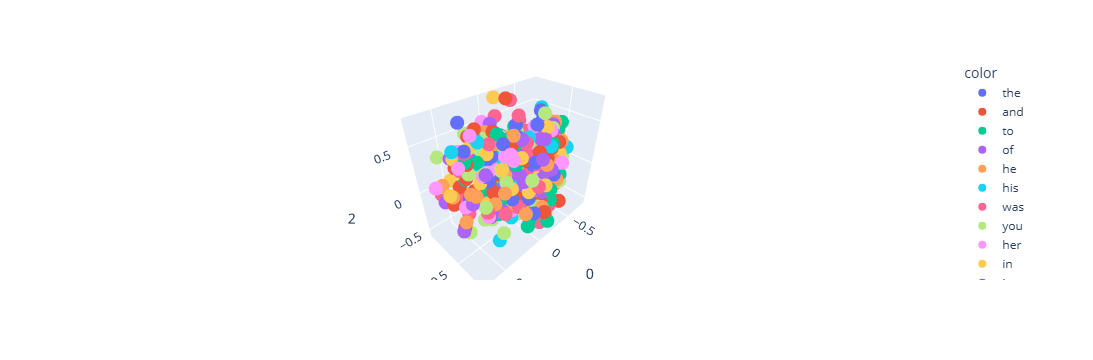

In [35]:
fig = px.scatter_3d(X[:500], x=0, y=1, z=2, color=y[:500])
fig.show()